# Phase 2 — Real Fermi GBM TTE GRB Detection Pipeline

This notebook demonstrates the Phase 2 implementation of **grbtrace** using **real Fermi GBM TTE FITS data**:
- download a public TTE FITS file
- extract photon/event times
- bin events into a light curve
- reuse Phase 1 modules for burst detection and feature extraction (T90)
- visualize the light curve and detected burst window

This phase focuses on *real data ingestion + binning*, while keeping the same detection/feature pipeline from Phase 1.

In [1]:
%cd /content
!rm -rf grbtrace
!git clone https://github.com/rshahri/grbtrace.git
%cd /content/grbtrace
!pip -q install scipy matplotlib

/content
Cloning into 'grbtrace'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 45 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 107.58 KiB | 4.48 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/grbtrace


In [2]:
!pip -q install astro-gdt-fermi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 21.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.


In [3]:
!pip -q install --upgrade --force-reinstall "numpy==1.26.4" "astropy==6.0.1"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
astro-gdt 2.2.2 requires astropy>=7.0.0, but you have astropy 6.0.1 which is incompatible.
astro-gdt 2.2.2 requires numpy>=2.2.3, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incom

In [5]:
from detect import detect_burst_threshold
from features import compute_t90, peak_rate, fluence_proxy
from plot import plot_lightcurve

In [4]:
import numpy as np
import astropy
print("numpy:", np.__version__)
print("astropy:", astropy.__version__)

numpy: 1.26.4
astropy: 6.0.1


In [6]:
%cd /content/grbtrace
!wget -q -O glg_ctime_n9_bn090131090_v01.pha \
  https://heasarc.gsfc.nasa.gov/FTP/fermi/data/gbm/triggers/2009/bn090131090/current/glg_ctime_n9_bn090131090_v01.pha

!ls -lh glg_ctime_n9_bn090131090_v01.pha
!file glg_ctime_n9_bn090131090_v01.pha

/content/grbtrace
-rw-r--r-- 1 root root 841K Apr 27  2009 glg_ctime_n9_bn090131090_v01.pha
glg_ctime_n9_bn090131090_v01.pha: FITS image data, 8-bit, character or unsigned binary integer


In [7]:
from astropy.io import fits

hdul = fits.open("glg_ctime_n9_bn090131090_v01.pha")
hdul.info()

Filename: glg_ctime_n9_bn090131090_v01.pha
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      37   ()      
  1  EBOUNDS       1 BinTableHDU     58   8R x 3C   [1I, 1E, 1E]   
  2  SPECTRUM      1 BinTableHDU     72   21820R x 5C   [8I, 1E, 1I, 1D, 1D]   
  3  GTI           1 BinTableHDU     44   1R x 2C   [1D, 1D]   


In [8]:
spec = hdul["SPECTRUM"].data
print(spec.columns)

ColDefs(
    name = 'COUNTS'; format = '8I'; unit = 'count'; bscale = 1; bzero = 32768
    name = 'EXPOSURE'; format = '1E'; unit = 's'
    name = 'QUALITY'; format = '1I'
    name = 'TIME'; format = '1D'; unit = 's'; bzero = 255060563.149072
    name = 'ENDTIME'; format = '1D'; unit = 's'; bzero = 255060563.149072
)


In [9]:
import numpy as np

spec = hdul["SPECTRUM"].data

t0 = np.array(spec["TIME"], dtype=float)
t1 = np.array(spec["ENDTIME"], dtype=float)
dt = np.median(t1 - t0)

# Sum across the 8 energy channels to get a total-count light curve
counts_8 = np.array(spec["COUNTS"], dtype=float)      # shape: (n_bins, 8)
counts = counts_8.sum(axis=1)                         # shape: (n_bins,)

# Use bin centers as time axis
t = 0.5 * (t0 + t1)

print("n_bins:", len(t))
print("dt (median):", dt)
print("counts shape:", counts.shape, "total counts:", counts.sum())
print("time range:", t.min(), "→", t.max())

n_bins: 21820
dt (median): 0.06400001049041748
counts shape: (21820,) total counts: 2486610.0
time range: 255059563.264512 → 255061563.82385403


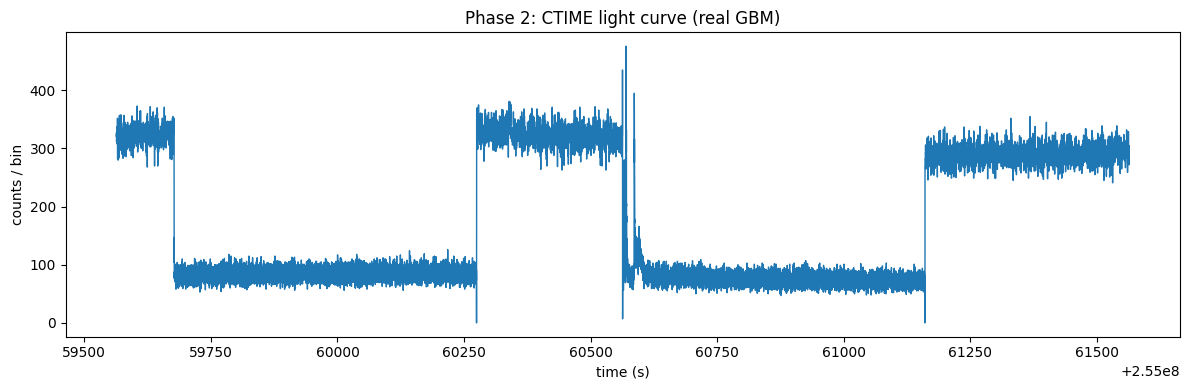

In [10]:
from plot import plot_lightcurve

plot_lightcurve(t, counts, title="Phase 2: CTIME light curve (real GBM)")

In [11]:
from detect import detect_burst_threshold

det = detect_burst_threshold(counts, sigma=5.0)
det

DetectionResult(start_idx=0, end_idx=21819, threshold=148.71700000000743, bkg_median=82.0, bkg_std_est=13.343400000001482)

In [12]:
from features import compute_t90, peak_rate, fluence_proxy

if det is None:
    print("No burst detected.")
else:
    window = (t[det.start_idx], t[det.end_idx])
    t90res = compute_t90(t, counts, det.start_idx, det.end_idx)

    print("=== Detection ===")
    print(f"Window: {window[0]:.3f}s → {window[1]:.3f}s")

    print("\n=== Features ===")
    if t90res:
        print(f"T90: {t90res.t90:.3f}s")
        print(f"Peak rate: {peak_rate(counts, dt):.1f}")
        print(f"Fluence proxy: {fluence_proxy(counts):.0f}")

=== Detection ===
Window: 255059563.265s → 255061563.824s

=== Features ===
T90: 1793.767s
Peak rate: 7437.5
Fluence proxy: 2486610


In [13]:
import numpy as np

imax = np.argmax(counts)
print("peak index:", imax)
print("peak time:", t[imax])

peak index: 11015
peak time: 255060570.029159


In [14]:
# ±20 seconds around peak
win_sec = 20
mask = (t > t[imax] - win_sec) & (t < t[imax] + win_sec)

t_local = t[mask]
counts_local = counts[mask]

In [15]:
det_local = detect_burst_threshold(counts_local, sigma=5.0)
det_local

DetectionResult(start_idx=0, end_idx=420, threshold=251.6730000000074, bkg_median=96.0, bkg_std_est=31.134600000001477)

In [16]:
# convert local indices back to global
global_indices = np.where(mask)[0]

start_global = global_indices[det_local.start_idx]
end_global = global_indices[det_local.end_idx]

start_global, end_global

(10856, 11276)

In [17]:
t90res = compute_t90(t, counts, start_global, end_global)

print("=== Detection ===")
print(f"Window: {t[start_global]:.3f}s → {t[end_global]:.3f}s")

print("\n=== Features ===")
print(f"T90: {t90res.t90:.3f}s")
print(f"Peak rate: {peak_rate(counts, dt):.1f}")
print(f"Fluence proxy: {fluence_proxy(counts):.0f}")

=== Detection ===
Window: 255060550.221s → 255060586.733s

=== Features ===
T90: 33.735s
Peak rate: 7437.5
Fluence proxy: 2486610
